In [3]:
import fastf1 as f1
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pandas as pd
import datetime as dt
import seaborn as sns
from fastf1 import plotting
from fastf1 import utils
from matplotlib import colors as mcolors
from matplotlib.ticker import FuncFormatter
f1.set_log_level("WARNING")
f1.Cache.enable_cache('../cache_strategy')

In [15]:
class F1Analyzer:
    ERAS_BASE_PENALTY = {
        "V10_LIGHT": 0.020,
        "V8_HYBRID": 0.025,
        "V6_TURBO": 0.030,
        "GROUND_EFFECT": 0.035,
    }

    DRS_GAINS = {
        'Bahrain': 0.90, 'Saudi Arabia': 0.85, 'Australia': 0.75,
        'Japan': 0.70, 'China': 0.95, 'Miami': 0.70,
        'Emilia Romagna': 0.65, 'Monaco': 0.20, 'Canada': 0.80,
        'Spain': 0.75, 'Austria': 0.80, 'Great Britain': 0.85,
        'Hungary': 0.55, 'Belgium': 1.20, 'Netherlands': 0.35,
        'Italy': 1.15, 'Azerbaijan': 1.10, 'Singapore': 0.60,
        'USA': 0.75, 'Mexico': 0.70, 'Brazil': 0.80,
        'Las Vegas': 1.25, 'Qatar': 0.80, 'Abu Dhabi': 0.95
    }

    DRS_EVENT_ALIASES = {
        'Bahrain Grand Prix': 'Bahrain',
        'Saudi Arabian Grand Prix': 'Saudi Arabia',
        'Australian Grand Prix': 'Australia',
        'Japanese Grand Prix': 'Japan',
        'Chinese Grand Prix': 'China',
        'Miami Grand Prix': 'Miami',
        'Emilia Romagna Grand Prix': 'Emilia Romagna',
        'Monaco Grand Prix': 'Monaco',
        'Canadian Grand Prix': 'Canada',
        'Spanish Grand Prix': 'Spain',
        'Austrian Grand Prix': 'Austria',
        'British Grand Prix': 'Great Britain',
        'Hungarian Grand Prix': 'Hungary',
        'Belgian Grand Prix': 'Belgium',
        'Dutch Grand Prix': 'Netherlands',
        'Italian Grand Prix': 'Italy',
        'Azerbaijan Grand Prix': 'Azerbaijan',
        'Singapore Grand Prix': 'Singapore',
        'United States Grand Prix': 'USA',
        'Mexico City Grand Prix': 'Mexico',
        'Sao Paulo Grand Prix': 'Brazil',
        'Las Vegas Grand Prix': 'Las Vegas',
        'Qatar Grand Prix': 'Qatar',
        'Abu Dhabi Grand Prix': 'Abu Dhabi',
    }

    TRACK_EVOLUTION_COEFFS = {
        'Las Vegas': -0.045,
        'Monaco': -0.035,
        'Azerbaijan': -0.035,
        'Saudi Arabia': -0.030,
        'Singapore': -0.030,
        'Miami': -0.025,
        'China': -0.025,
        'Bahrain': -0.018,
        'Abu Dhabi': -0.018,
        'USA': -0.015,
        'Mexico': -0.015,
        'Qatar': -0.015,
        'Australia': -0.015,
        'Austria': -0.012,
        'Emilia Romagna': -0.012,
        'Canada': -0.020,
        'Spain': -0.008,
        'Great Britain': -0.008,
        'Japan': -0.007,
        'Belgium': -0.010,
        'Italy': -0.010,
        'Netherlands': -0.009,
        'Brazil': -0.010
    }

    DEFAULT_DRS_OPEN_STATES = (10, 12, 14)

    def _calculate_auto_penalty(self, year, grand_prix):
        if year <= 2005:
            era = "V10_LIGHT"
        elif year <= 2013:
            era = "V8_HYBRID"
        elif year <= 2021:
            era = "V6_TURBO"
        else:
            era = "GROUND_EFFECT"

        base = self.ERAS_BASE_PENALTY[era]

        POWER_TRACKS = {'Monza', 'Spa-Francorchamps', 'Silverstone', 'Baku City Circuit', 'Las Vegas', 'Jeddah Corniche Circuit'}
        STREET_TRACKS = {'Monaco', 'Singapore Street Circuit', 'Hungaroring', 'Marina Bay Street Circuit'}

        if grand_prix in POWER_TRACKS:
            modifier, cat = 1.2, "POWER"
        elif grand_prix in STREET_TRACKS:
            modifier, cat = 0.7, "STREET"
        else:
            modifier, cat = 1.0, "BALANCED"

        return base * modifier, cat

    def _normalize_session_type(self, session_type):
        aliases = {
            "EL1": "FP1",
            "EL2": "FP2",
            "EL3": "FP3",
            "P1": "FP1",
            "P2": "FP2",
            "P3": "FP3",
        }
        return aliases.get(session_type, session_type)

    def _resolve_drs_gain_key(self):
        event_name = str(self.session.event.get('EventName', self.grand_prix))
        return self.DRS_EVENT_ALIASES.get(event_name, self.grand_prix)

    def _compute_drs_open_percentage(self, lap, drs_open_states=None):
        if drs_open_states is None:
            drs_open_states = set(self.DEFAULT_DRS_OPEN_STATES)
        else:
            drs_open_states = set(drs_open_states)

        try:
            car = lap.get_car_data()
            if 'DRS' not in car.columns:
                return 0.0

            drs_series = car['DRS'].dropna().astype(int)
            if drs_series.empty:
                return 0.0

            drs_open_mask = drs_series.isin(drs_open_states)
            return float(drs_open_mask.mean() * 100.0)
        except Exception:
            return 0.0

    def add_drs_correction_to_laps(
        self,
        laps,
        drs_activation_min_pct=10.0,
        fallback_gain=0.80,
        drs_open_states=None
    ):
        laps = laps.copy()
        if laps.empty:
            laps['DRS_Open_Percentage'] = np.nan
            laps['DRS_Time_Add_s'] = np.nan
            laps['CorrectedLapTime_DRSOnly'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        gain_key = self._resolve_drs_gain_key()
        drs_gain_s = float(self.DRS_GAINS.get(gain_key, fallback_gain))

        drs_pct_by_index = {}
        drs_add_by_index = {}

        if hasattr(laps, 'iterlaps'):
            iterator = laps.iterlaps()
        else:
            iterator = []

        for idx, lap in iterator:
            drs_pct = self._compute_drs_open_percentage(lap, drs_open_states=drs_open_states)
            drs_add = drs_gain_s * (drs_pct / 100.0) if drs_pct >= drs_activation_min_pct else 0.0
            drs_pct_by_index[idx] = drs_pct
            drs_add_by_index[idx] = drs_add

        laps['DRS_Open_Percentage'] = laps.index.map(lambda i: drs_pct_by_index.get(i, np.nan))
        laps['DRS_Time_Add_s'] = laps.index.map(lambda i: drs_add_by_index.get(i, np.nan))

        lap_time_sec = laps['LapTime'].dt.total_seconds()
        laps['CorrectedLapTime_DRSOnly'] = lap_time_sec + laps['DRS_Time_Add_s'].fillna(0.0)

        if 'CorrectedLapTime' in laps.columns:
            laps['CorrectedLapTime_Global'] = laps['CorrectedLapTime'] + laps['DRS_Time_Add_s'].fillna(0.0)
        else:
            laps['CorrectedLapTime_Global'] = laps['CorrectedLapTime_DRSOnly']

        return laps

    def _dirty_air_multiplier(self, gap_s):
        if pd.isna(gap_s):
            return 0.0
        if gap_s <= 0.5:
            return 1.2
        if gap_s <= 1.2:
            return 1.0
        if gap_s <= 2.0:
            return 0.5
        return 0.0

    def _to_seconds_series(self, series):
        if series is None:
            return None
        if pd.api.types.is_timedelta64_dtype(series):
            return series.dt.total_seconds()
        if pd.api.types.is_numeric_dtype(series):
            return pd.to_numeric(series, errors='coerce')
        cleaned = series.astype(str).str.replace('+', '', regex=False).str.replace('s', '', regex=False).str.strip()
        return pd.to_numeric(cleaned, errors='coerce')

    def _compute_gap_to_ahead_from_laps(self, laps):
        gap = pd.Series(np.nan, index=laps.index, dtype=float)

        required = {'LapNumber', 'Position', 'Time'}
        if not required.issubset(laps.columns):
            return gap

        work = laps[['LapNumber', 'Position', 'Time']].copy()
        work = work.dropna(subset=['LapNumber', 'Position', 'Time'])
        if work.empty:
            return gap

        for _, grp in work.groupby('LapNumber'):
            grp_sorted = grp.sort_values('Position')
            gap_values = (grp_sorted['Time'] - grp_sorted['Time'].shift(1)).dt.total_seconds()
            gap.loc[grp_sorted.index] = gap_values

        return gap

    def add_dirty_air_correction_to_laps(
        self,
        laps,
        dirty_air_scale=0.35,
        gap_column=None,
    ):
        laps = laps.copy()
        if laps.empty:
            laps['Gap_Ahead_s'] = np.nan
            laps['DirtyAir_M'] = np.nan
            laps['DirtyAirPenalty_s'] = np.nan
            laps['CorrectedLapTime_DirtyAir'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        gap_s = None
        if gap_column is not None and gap_column in laps.columns:
            gap_s = self._to_seconds_series(laps[gap_column])
        if gap_s is None:
            for candidate in ['GapToAhead_s', 'GapToAhead', 'IntervalToPositionAhead', 'IntervalToPositionAhead_s']:
                if candidate in laps.columns:
                    gap_s = self._to_seconds_series(laps[candidate])
                    break
        if gap_s is None:
            gap_s = self._compute_gap_to_ahead_from_laps(laps)

        laps['Gap_Ahead_s'] = gap_s
        laps['DirtyAir_M'] = laps['Gap_Ahead_s'].apply(self._dirty_air_multiplier)
        laps['DirtyAirPenalty_s'] = dirty_air_scale * laps['DirtyAir_M']
        laps['CorrectedLapTime_DirtyAir'] = laps['LapTime'].dt.total_seconds() - laps['DirtyAirPenalty_s']

        if 'CorrectedLapTime_Global' in laps.columns:
            base_global = laps['CorrectedLapTime_Global']
        elif 'CorrectedLapTime' in laps.columns:
            base_global = laps['CorrectedLapTime']
        else:
            base_global = laps['LapTime'].dt.total_seconds()

        laps['CorrectedLapTime_Global'] = base_global - laps['DirtyAirPenalty_s']

        return laps

    def _resolve_track_evolution_key(self):
        event_name = str(self.session.event.get('EventName', self.grand_prix))
        return self.DRS_EVENT_ALIASES.get(event_name, self.grand_prix)

    def add_track_evolution_correction_to_laps(self, laps):
        laps = laps.copy()
        if laps.empty:
            laps['TrackEvolutionCoeff'] = np.nan
            laps['TrackEvolutionDelta_s'] = np.nan
            laps['CorrectedLapTime_TrackEvolution'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        track_key = self._resolve_track_evolution_key()
        track_coeff = float(self.TRACK_EVOLUTION_COEFFS.get(track_key, 0.0))

        laps['TrackEvolutionCoeff'] = track_coeff
        laps['TrackEvolutionDelta_s'] = laps['LapNumber'] * track_coeff
        laps['CorrectedLapTime_TrackEvolution'] = laps['LapTime'].dt.total_seconds() + laps['TrackEvolutionDelta_s']

        if 'CorrectedLapTime_Global' in laps.columns:
            base_global = laps['CorrectedLapTime_Global']
        elif 'CorrectedLapTime' in laps.columns:
            base_global = laps['CorrectedLapTime']
        else:
            base_global = laps['LapTime'].dt.total_seconds()

        laps['CorrectedLapTime_Global'] = base_global + laps['TrackEvolutionDelta_s']

        return laps

    def _get_lap_track_temperature(self, lap):
        try:
            weather = lap.get_weather_data()
            if weather is not None and 'TrackTemp' in weather.index:
                value = weather['TrackTemp']
                if pd.notna(value):
                    return float(value)
        except Exception:
            pass
        return np.nan

    def add_temperature_correction_to_laps(
        self,
        laps,
        reference_track_temp=35.0,
        temp_coeff=0.015
    ):
        laps = laps.copy()
        if laps.empty:
            laps['TrackTemp_C'] = np.nan
            laps['TempCorrection_s'] = np.nan
            laps['CorrectedLapTime_Temp'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        track_temp_by_idx = {}
        if hasattr(laps, 'iterlaps'):
            iterator = laps.iterlaps()
        else:
            iterator = []

        for idx, lap in iterator:
            track_temp_by_idx[idx] = self._get_lap_track_temperature(lap)

        if len(track_temp_by_idx) > 0:
            laps['TrackTemp_C'] = laps.index.map(lambda i: track_temp_by_idx.get(i, np.nan))
        elif 'TrackTemp' in laps.columns:
            laps['TrackTemp_C'] = pd.to_numeric(laps['TrackTemp'], errors='coerce')
        else:
            laps['TrackTemp_C'] = np.nan

        laps['TempCorrection_s'] = temp_coeff * (laps['TrackTemp_C'] - reference_track_temp)
        laps['CorrectedLapTime_Temp'] = laps['LapTime'].dt.total_seconds() - laps['TempCorrection_s']

        if 'CorrectedLapTime_Global' in laps.columns:
            base_global = laps['CorrectedLapTime_Global']
        elif 'CorrectedLapTime' in laps.columns:
            base_global = laps['CorrectedLapTime']
        else:
            base_global = laps['LapTime'].dt.total_seconds()

        laps['CorrectedLapTime_Global'] = base_global - laps['TempCorrection_s']

        return laps

    def __init__(self, year, grand_prix, session_type, use_fuel_logic=True):
        self.year = year
        self.grand_prix = grand_prix
        self.session_type = self._normalize_session_type(session_type)
        self.session = f1.get_session(year, grand_prix, self.session_type)
        self.session.load(laps=True, telemetry=True, weather=True, messages=True)
        if use_fuel_logic:
            self.fuel_penalty, self.circuit_category = self._calculate_auto_penalty(year, grand_prix)
        else:
            self.fuel_penalty, self.circuit_category = 0, "NONE"

        self.session.laps['CircuitCategory'] = self.circuit_category
        self.session.laps['FuelPenaltyFactor'] = self.fuel_penalty
        self.session.laps['CorrectedLapTime'] = (
            self.session.laps['LapTime'].dt.total_seconds() +
            (self.session.laps['LapNumber'] * self.fuel_penalty)
        )

    def get_clean_laps(self, driver):
        laps = self.session.laps.pick_driver(driver)
        clean_1_laps = laps.loc[
            (laps["PitInTime"].isna()) &
            (laps["PitOutTime"].isna()) &
            (laps["TrackStatus"] == "1")
        ].copy()
        return clean_1_laps

    def audit_data_cleaning(self, driver):
        raw_laps = self.session.laps.pick_driver(driver)
        total_raw = len(raw_laps)

        phys_clean = self.get_clean_laps(driver)
        total_phys = len(phys_clean)

        very_clean = self.get_clean_race_pace_laps(driver)
        total_very = len(very_clean)

        raw_lap_numbers = set(raw_laps["LapNumber"].dropna().astype(int).tolist())
        phys_lap_numbers = set(phys_clean["LapNumber"].dropna().astype(int).tolist())
        very_lap_numbers = set(very_clean["LapNumber"].dropna().astype(int).tolist())

        lost_phys_laps = sorted(raw_lap_numbers - phys_lap_numbers)
        lost_iqr_laps = sorted(phys_lap_numbers - very_lap_numbers)

        lost_phys = len(lost_phys_laps)
        lost_iqr = len(lost_iqr_laps)

        pct_phys = (lost_phys / total_raw) * 100 if total_raw else 0
        pct_iqr = (lost_iqr / total_phys) * 100 if total_phys else 0

        print(f"--- Audit de Nettoyage pour {driver} ---")
        print(f"Tours totaux en session : {total_raw}")
        print(f"Tours perdus (Stands/Drapeaux) : {lost_phys} ({pct_phys:.1f}%)")
        print(f"Numéros des tours perdus (Stands/Drapeaux) : {lost_phys_laps if lost_phys_laps else 'Aucun'}")
        print(f"Tours perdus (IQR/Anomalies) : {lost_iqr} ({pct_iqr:.1f}%)")
        print(f"Numéros des tours perdus (IQR/Anomalies) : {lost_iqr_laps if lost_iqr_laps else 'Aucun'}")
        print(f"Tours restants pour l'analyse : {total_very}")
        print("-" * 40)

        return total_raw, total_phys, total_very, lost_iqr, lost_phys

    def get_clean_race_pace_laps(self, driver):
        laps = self.get_clean_laps(driver)
        series = laps["LapTime"].dt.total_seconds()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        clean_2_laps = laps[(series >= lower_bound) & (series <= upper_bound)]
        return clean_2_laps

    def format_laptime(self, seconds, pos):
        minutes = int(seconds // 60)
        remainder = seconds % 60
        return f"{minutes}:{remainder:06.3f}"

    def plot_drivers_pace(
        self,
        session,
        driver_list,
        very_clean=False,
        include_nan_laps=False,
        use_fuel_logic=False,
        use_drs_correction=False,
        use_dirty_air_correction=False,
        use_track_evolution_correction=False,
        use_temperature_correction=False,
        mode=None,
        drs_activation_min_pct=10.0,
        fallback_drs_gain=0.80,
        dirty_air_scale=0.35,
        reference_track_temp=35.0,
        temp_coeff=0.015
    ):
        # mode: 'raw' | 'fuel' | 'drs_only' | 'dirty_air_only' | 'track_evolution_only' | 'temperature_only' | 'global'
        if mode is None:
            if use_fuel_logic and use_drs_correction and use_dirty_air_correction and use_track_evolution_correction and use_temperature_correction:
                selected_mode = 'global'
            elif use_temperature_correction:
                selected_mode = 'temperature_only'
            elif use_track_evolution_correction:
                selected_mode = 'track_evolution_only'
            elif use_dirty_air_correction:
                selected_mode = 'dirty_air_only'
            elif use_fuel_logic:
                selected_mode = 'fuel'
            elif use_drs_correction:
                selected_mode = 'drs_only'
            else:
                selected_mode = 'raw'
        else:
            selected_mode = str(mode).lower()

        valid_modes = {'raw', 'fuel', 'drs_only', 'dirty_air_only', 'track_evolution_only', 'temperature_only', 'global'}
        if selected_mode not in valid_modes:
            raise ValueError(f"mode invalide: {selected_mode}. Utilise {sorted(valid_modes)}")

        fig, ax = plt.subplots(figsize=(12, 7))
        used_colors = {}

        for driver in driver_list:
            if very_clean:
                laps = self.get_clean_race_pace_laps(driver)
            else:
                laps = self.get_clean_laps(driver)

            if selected_mode in {'drs_only', 'global'}:
                laps = self.add_drs_correction_to_laps(
                    laps,
                    drs_activation_min_pct=drs_activation_min_pct,
                    fallback_gain=fallback_drs_gain
                )

            if selected_mode in {'dirty_air_only', 'global'}:
                laps = self.add_dirty_air_correction_to_laps(
                    laps,
                    dirty_air_scale=dirty_air_scale
                )

            if selected_mode in {'track_evolution_only', 'global'}:
                laps = self.add_track_evolution_correction_to_laps(laps)

            if selected_mode in {'temperature_only', 'global'}:
                laps = self.add_temperature_correction_to_laps(
                    laps,
                    reference_track_temp=reference_track_temp,
                    temp_coeff=temp_coeff
                )

            if include_nan_laps:
                if self.session.total_laps is not None:
                    max_lap = int(self.session.total_laps)
                else:
                    lap_numbers = self.session.laps["LapNumber"].dropna()
                    max_lap = int(lap_numbers.max()) if not lap_numbers.empty else 0

                if max_lap > 0:
                    full_range = range(1, max_lap + 1)
                    laps = laps.set_index("LapNumber").reindex(full_range).reset_index()

            if selected_mode == 'global':
                if "CorrectedLapTime_Global" not in laps.columns or laps["CorrectedLapTime_Global"].notna().sum() == 0:
                    continue
                y = laps["CorrectedLapTime_Global"]
            elif selected_mode == 'fuel':
                if "CorrectedLapTime" not in laps.columns or laps["CorrectedLapTime"].notna().sum() == 0:
                    continue
                y = laps["CorrectedLapTime"]
            elif selected_mode == 'drs_only':
                if "CorrectedLapTime_DRSOnly" not in laps.columns or laps["CorrectedLapTime_DRSOnly"].notna().sum() == 0:
                    continue
                y = laps["CorrectedLapTime_DRSOnly"]
            elif selected_mode == 'dirty_air_only':
                if "CorrectedLapTime_DirtyAir" not in laps.columns or laps["CorrectedLapTime_DirtyAir"].notna().sum() == 0:
                    continue
                y = laps["CorrectedLapTime_DirtyAir"]
            elif selected_mode == 'track_evolution_only':
                if "CorrectedLapTime_TrackEvolution" not in laps.columns or laps["CorrectedLapTime_TrackEvolution"].notna().sum() == 0:
                    continue
                y = laps["CorrectedLapTime_TrackEvolution"]
            elif selected_mode == 'temperature_only':
                if "CorrectedLapTime_Temp" not in laps.columns or laps["CorrectedLapTime_Temp"].notna().sum() == 0:
                    continue
                y = laps["CorrectedLapTime_Temp"]
            else:
                if laps.empty or laps["LapTime"].notna().sum() == 0:
                    continue
                y = laps["LapTime"].dt.total_seconds()

            x = laps["LapNumber"]

            try:
                base_color = plotting.get_driver_color(driver, session=session)
            except Exception:
                base_color = "#FFFFFF"

            if base_color in used_colors.values():
                rgb = mcolors.to_rgb(base_color)
                color = mcolors.to_hex([min(1, c + 0.4) for c in rgb])
                linestyle = "--"
            else:
                color = base_color
                linestyle = "-"
                used_colors[driver] = base_color

            ax.plot(
                x,
                y,
                color=color,
                label=driver,
                linestyle=linestyle,
                linewidth=2,
                marker="o",
                markersize=3,
                alpha=0.8,
            )

        ax.yaxis.set_major_formatter(FuncFormatter(self.format_laptime))

        title = f"Race Pace Analysis: {session.event['EventName']} {session.event.year}"
        ax.set_title(title, fontsize=15, pad=20)
        ax.set_xlabel("Tour n°", fontsize=12)

        ylabel_by_mode = {
            'raw': "Temps au tour",
            'fuel': "Temps au tour corrigé (fuel)",
            'drs_only': "Temps au tour corrigé (DRS only)",
            'dirty_air_only': "Temps au tour corrigé (dirty air)",
            'track_evolution_only': "Temps au tour corrigé (track evolution)",
            'temperature_only': "Temps au tour corrigé (temperature normalize)",
            'global': "Temps au tour corrigé (fuel + DRS + dirty air + track evolution + temperature)",
        }
        ax.set_ylabel(ylabel_by_mode[selected_mode], fontsize=12)

        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
        ax.grid(visible=True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        return fig, ax

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


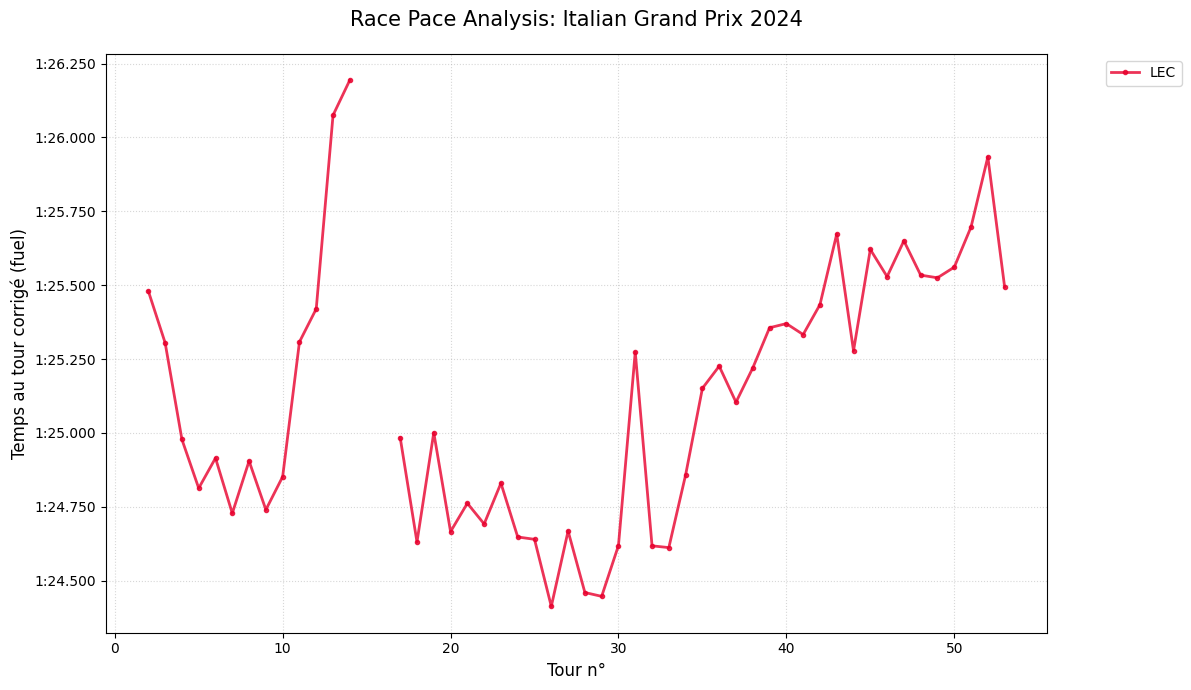

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


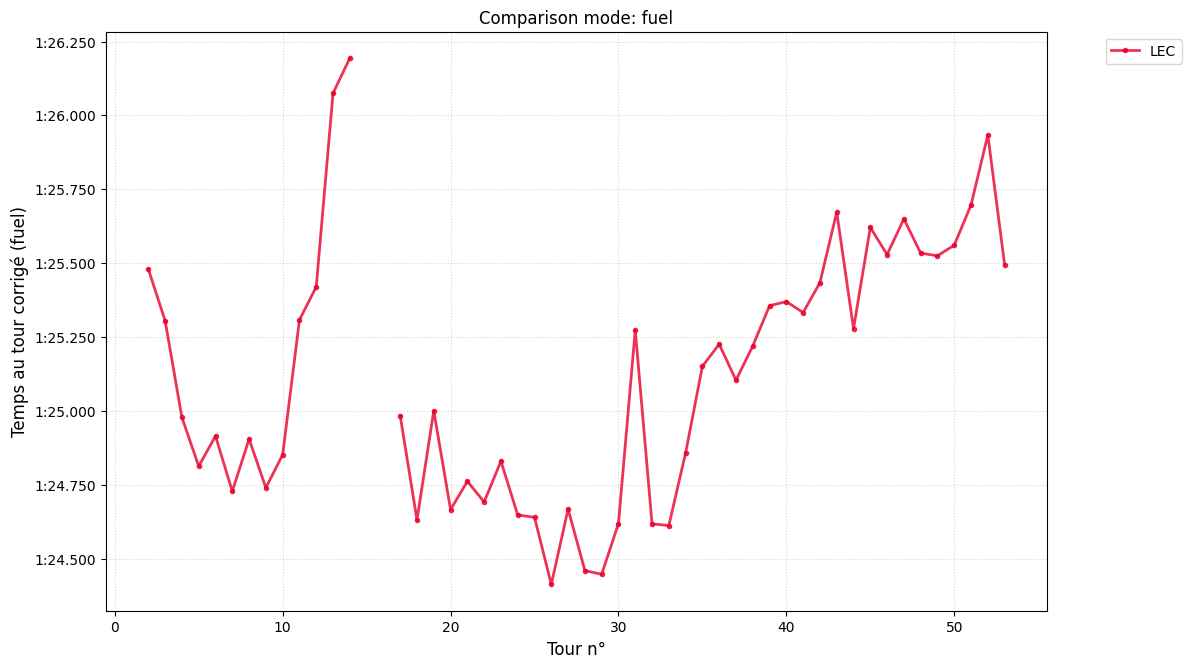

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


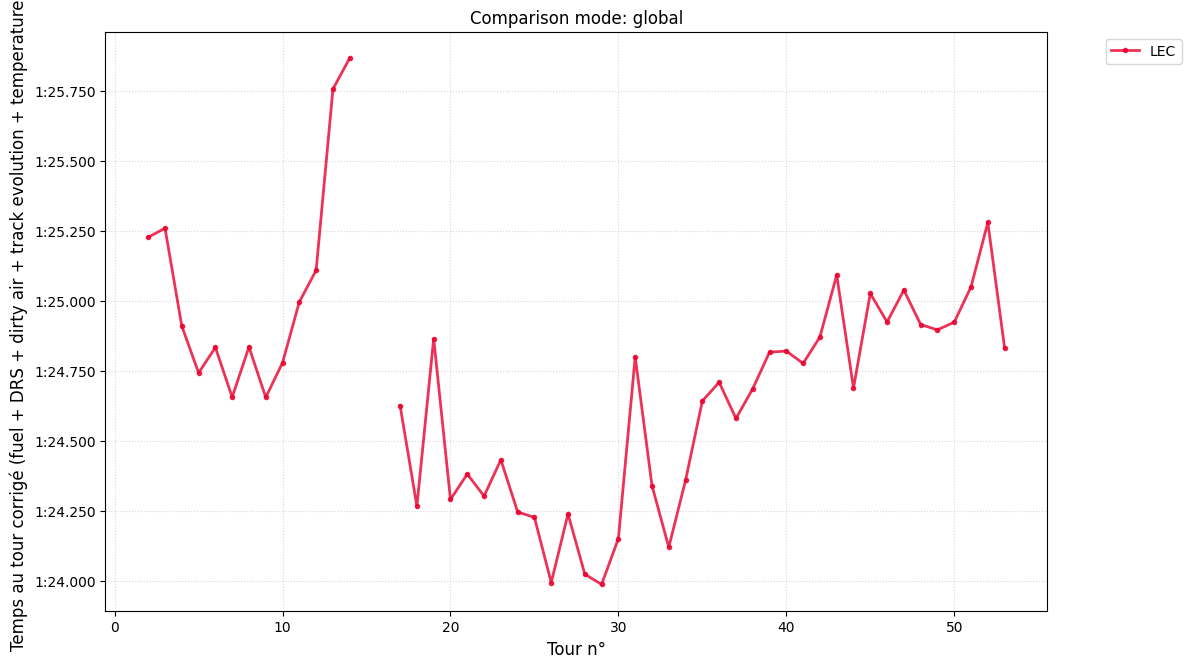

In [17]:
analyzing_monza = F1Analyzer(2024, 'Monza', 'R')

# Mode unique et clair:
# 'raw' | 'fuel' | 'drs_only' | 'global'
plot_mode = 'fuel'

drs_activation_min_pct = 12.0

fig, ax = analyzing_monza.plot_drivers_pace(
    analyzing_monza.session,
    ['LEC'],
    very_clean=True,
    include_nan_laps=True,
    mode=plot_mode,
    drs_activation_min_pct=drs_activation_min_pct    
)
plt.show()

# Exemple comparaison: fuel vs global
for m in ['fuel', 'global']:
    fig, ax = analyzing_monza.plot_drivers_pace(
        analyzing_monza.session,
        ['LEC'],
        very_clean=True,
        include_nan_laps=True,
        mode=m,
        drs_activation_min_pct=drs_activation_min_pct
    )
    plt.title(f"Comparison mode: {m}")
    plt.show()